In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install easyocr -q


In [2]:
import pytesseract
import cv2
import easyocr
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


In [3]:
def create_receipt():
    img = Image.new('RGB', (600, 900), color='white')
    draw = ImageDraw.Draw(img)

    draw.text((250, 50), 'MY STORE', fill='black')
    draw.text((50, 150), 'Date: 04/22/2026', fill='black')
    draw.text((50, 200), 'Burger     $5.00', fill='black')
    draw.text((50, 240), 'Fries      $3.00', fill='black')
    draw.text((50, 280), 'Drink      $2.00', fill='black')
    draw.text((50, 350), 'TOTAL: $10.00', fill='black')

    img.save('receipt1.jpg')
    print("Receipt Created!")

create_receipt()
img_path = "receipt1.jpg"


Receipt Created!


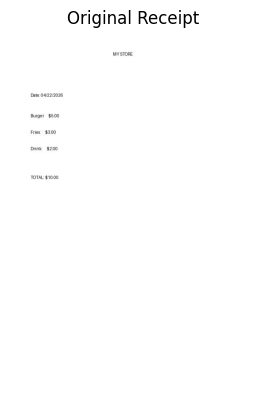

In [4]:
img = Image.open(img_path)

plt.imshow(img)
plt.title("Original Receipt")
plt.axis("off")
plt.show()


In [5]:
text = pytesseract.image_to_string(img)

print("=== TESSERACT OUTPUT ===")
print(text)


=== TESSERACT OUTPUT ===
MY STORE

Date: 04/22/2028

Burger $500

Fries $300

Drink $200

TOTAL $10.00



In [6]:
data = pytesseract.image_to_data(img, output_type='dict')
df = pd.DataFrame(data)

df = df[df['text'].str.strip() != '']
df = df[df['conf'] != -1]

print("=== CONFIDENCE SCORES ===")
print(df[['text', 'conf']])
print("Average Confidence:", df['conf'].mean())


=== CONFIDENCE SCORES ===
          text  conf
4           MY    31
5        STORE    31
9        Date:    17
10  04/22/2028    17
14      Burger    62
15        $500    71
19       Fries    74
20        $300    80
24       Drink    79
25        $200    79
29       TOTAL    93
30      $10.00    87
Average Confidence: 60.083333333333336


In [7]:
reader = easyocr.Reader(['en'])
result = reader.readtext(img_path)

print("=== EASYOCR OUTPUT ===")
for r in result:
    print(f"Text: {r[1]} | Confidence: {r[2]:.2f}")


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EASYOCR OUTPUT ===
Text: MY STORE | Confidence: 0.65
Text: Date. 04/22/2026 | Confidence: 0.31
Text: Burger | Confidence: 0.98
Text: $5.00 | Confidence: 0.82
Text: Fries | Confidence: 0.99
Text: $3.00 | Confidence: 0.88
Text: Drink | Confidence: 1.00
Text: $2.00 | Confidence: 0.85
Text: TOTAL: $10.00 | Confidence: 0.62


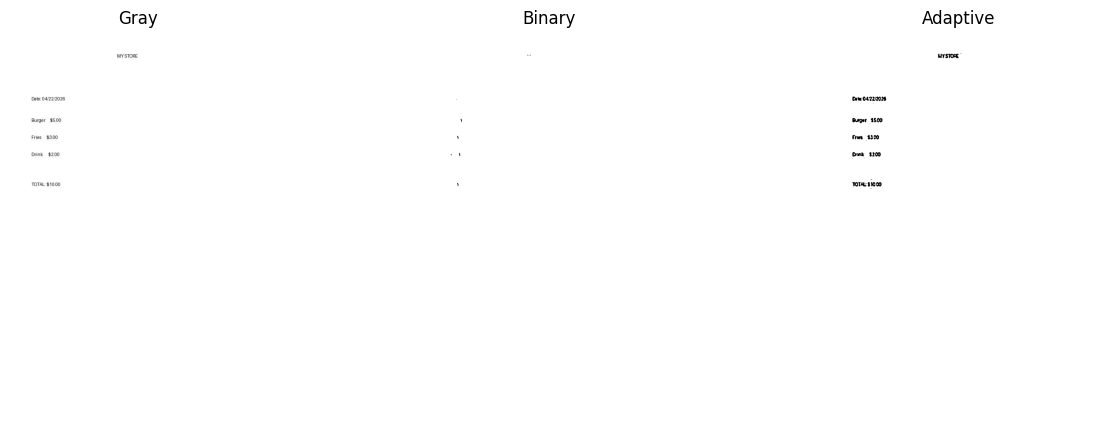

In [8]:
img_cv = cv2.imread(img_path)

gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

binary = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)[1]

adaptive = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

# Show images
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Gray")

axes[1].imshow(binary, cmap='gray')
axes[1].set_title("Binary")

axes[2].imshow(adaptive, cmap='gray')
axes[2].set_title("Adaptive")

for ax in axes:
    ax.axis("off")

plt.show()


In [9]:
text2 = pytesseract.image_to_string(adaptive)

print("=== AFTER PREPROCESSING ===")
print(text2)


=== AFTER PREPROCESSING ===
wy STOR

Gre 042272008

Gager $500
Frm $300,

Grek $200

TOTAL $1000



In [10]:
print("Original Length:", len(text))
print("Processed Length:", len(text2))


Original Length: 79
Processed Length: 70


In [11]:
def compare_ocr_methods(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    tess_text = pytesseract.image_to_string(Image.fromarray(thresh))

    easy_res = reader.readtext(image_path)
    easy_text = " ".join([r[1] for r in easy_res])

    return tess_text, easy_text

tess, easy = compare_ocr_methods(img_path)

print("Tesseract Length:", len(tess))
print("EasyOCR Length:", len(easy))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tesseract Length: 70
EasyOCR Length: 76
